In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [87]:
# definindo caminho para salvamento das figuras, conforme pedido.

FIGURES_PATH = '../reports/figures'
os.makedirs(FIGURES_PATH, exist_ok=True)

In [88]:
df = pd.read_csv('../data/raw/diabetes_dataset.csv')

In [89]:
df

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,...,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0
99996,41,Female,White,Graduate,Middle,Employed,Never,3,76,8.8,...,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0
99997,57,Female,Black,No formal,Upper-Middle,Employed,Former,4,121,9.9,...,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0
99998,47,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52,5.9,...,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0


In [90]:
df.shape

(100000, 31)

In [91]:
print("Estatísticas Descritivas (Variáveis Numéricas)")
display(df.describe().transpose())

Estatísticas Descritivas (Variáveis Numéricas)


,count,mean,std,min,25%,50%,75%,max
age,100000.0,50.120410,15.604600,18.00,39.00,50.00,61.00,90.00
alcohol_consumption_per_week,100000.0,2.003670,1.417779,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,100000.0,118.911640,84.409662,0.00,57.00,100.00,160.00,833.00
diet_score,100000.0,5.994787,1.780954,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,100000.0,6.997818,1.094622,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,100000.0,5.996468,2.468406,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,100000.0,0.219410,0.413849,0.00,0.00,0.00,0.00,1.00
hypertension_history,100000.0,0.250800,0.433476,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,100000.0,0.079200,0.270052,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,25.612653,3.586705,15.00,23.20,25.60,28.00,39.20


In [92]:
print(df.duplicated().sum())

0


In [93]:
df.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


Não foram encontrados dados faltantes

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [95]:
categorical_cols = ['gender', 'ethnicity', 'education_level', 'income_level',
                        'employment_status', 'smoking_status', 'diabetes_stage']
for col in categorical_cols:
    if col in df.columns:
        print(f"\nValores em '{col}':")
        print(df[col].value_counts(dropna=False))


Valores em 'gender':
gender
Female    50216
Male      47771
Other      2013
Name: count, dtype: int64

Valores em 'ethnicity':
ethnicity
White       44997
Hispanic    20103
Black       17986
Asian       11865
Other        5049
Name: count, dtype: int64

Valores em 'education_level':
education_level
Highschool      44891
Graduate        35037
Postgraduate    14972
No formal        5100
Name: count, dtype: int64

Valores em 'income_level':
income_level
Middle          35152
Lower-Middle    25150
Upper-Middle    19866
Low             14830
High             5002
Name: count, dtype: int64

Valores em 'employment_status':
employment_status
Employed      60175
Retired       21761
Unemployed    11918
Student        6146
Name: count, dtype: int64

Valores em 'smoking_status':
smoking_status
Never      59813
Current    20176
Former     20011
Name: count, dtype: int64

Valores em 'diabetes_stage':
diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       

# Análise Exploratória dos Dados (EDA)

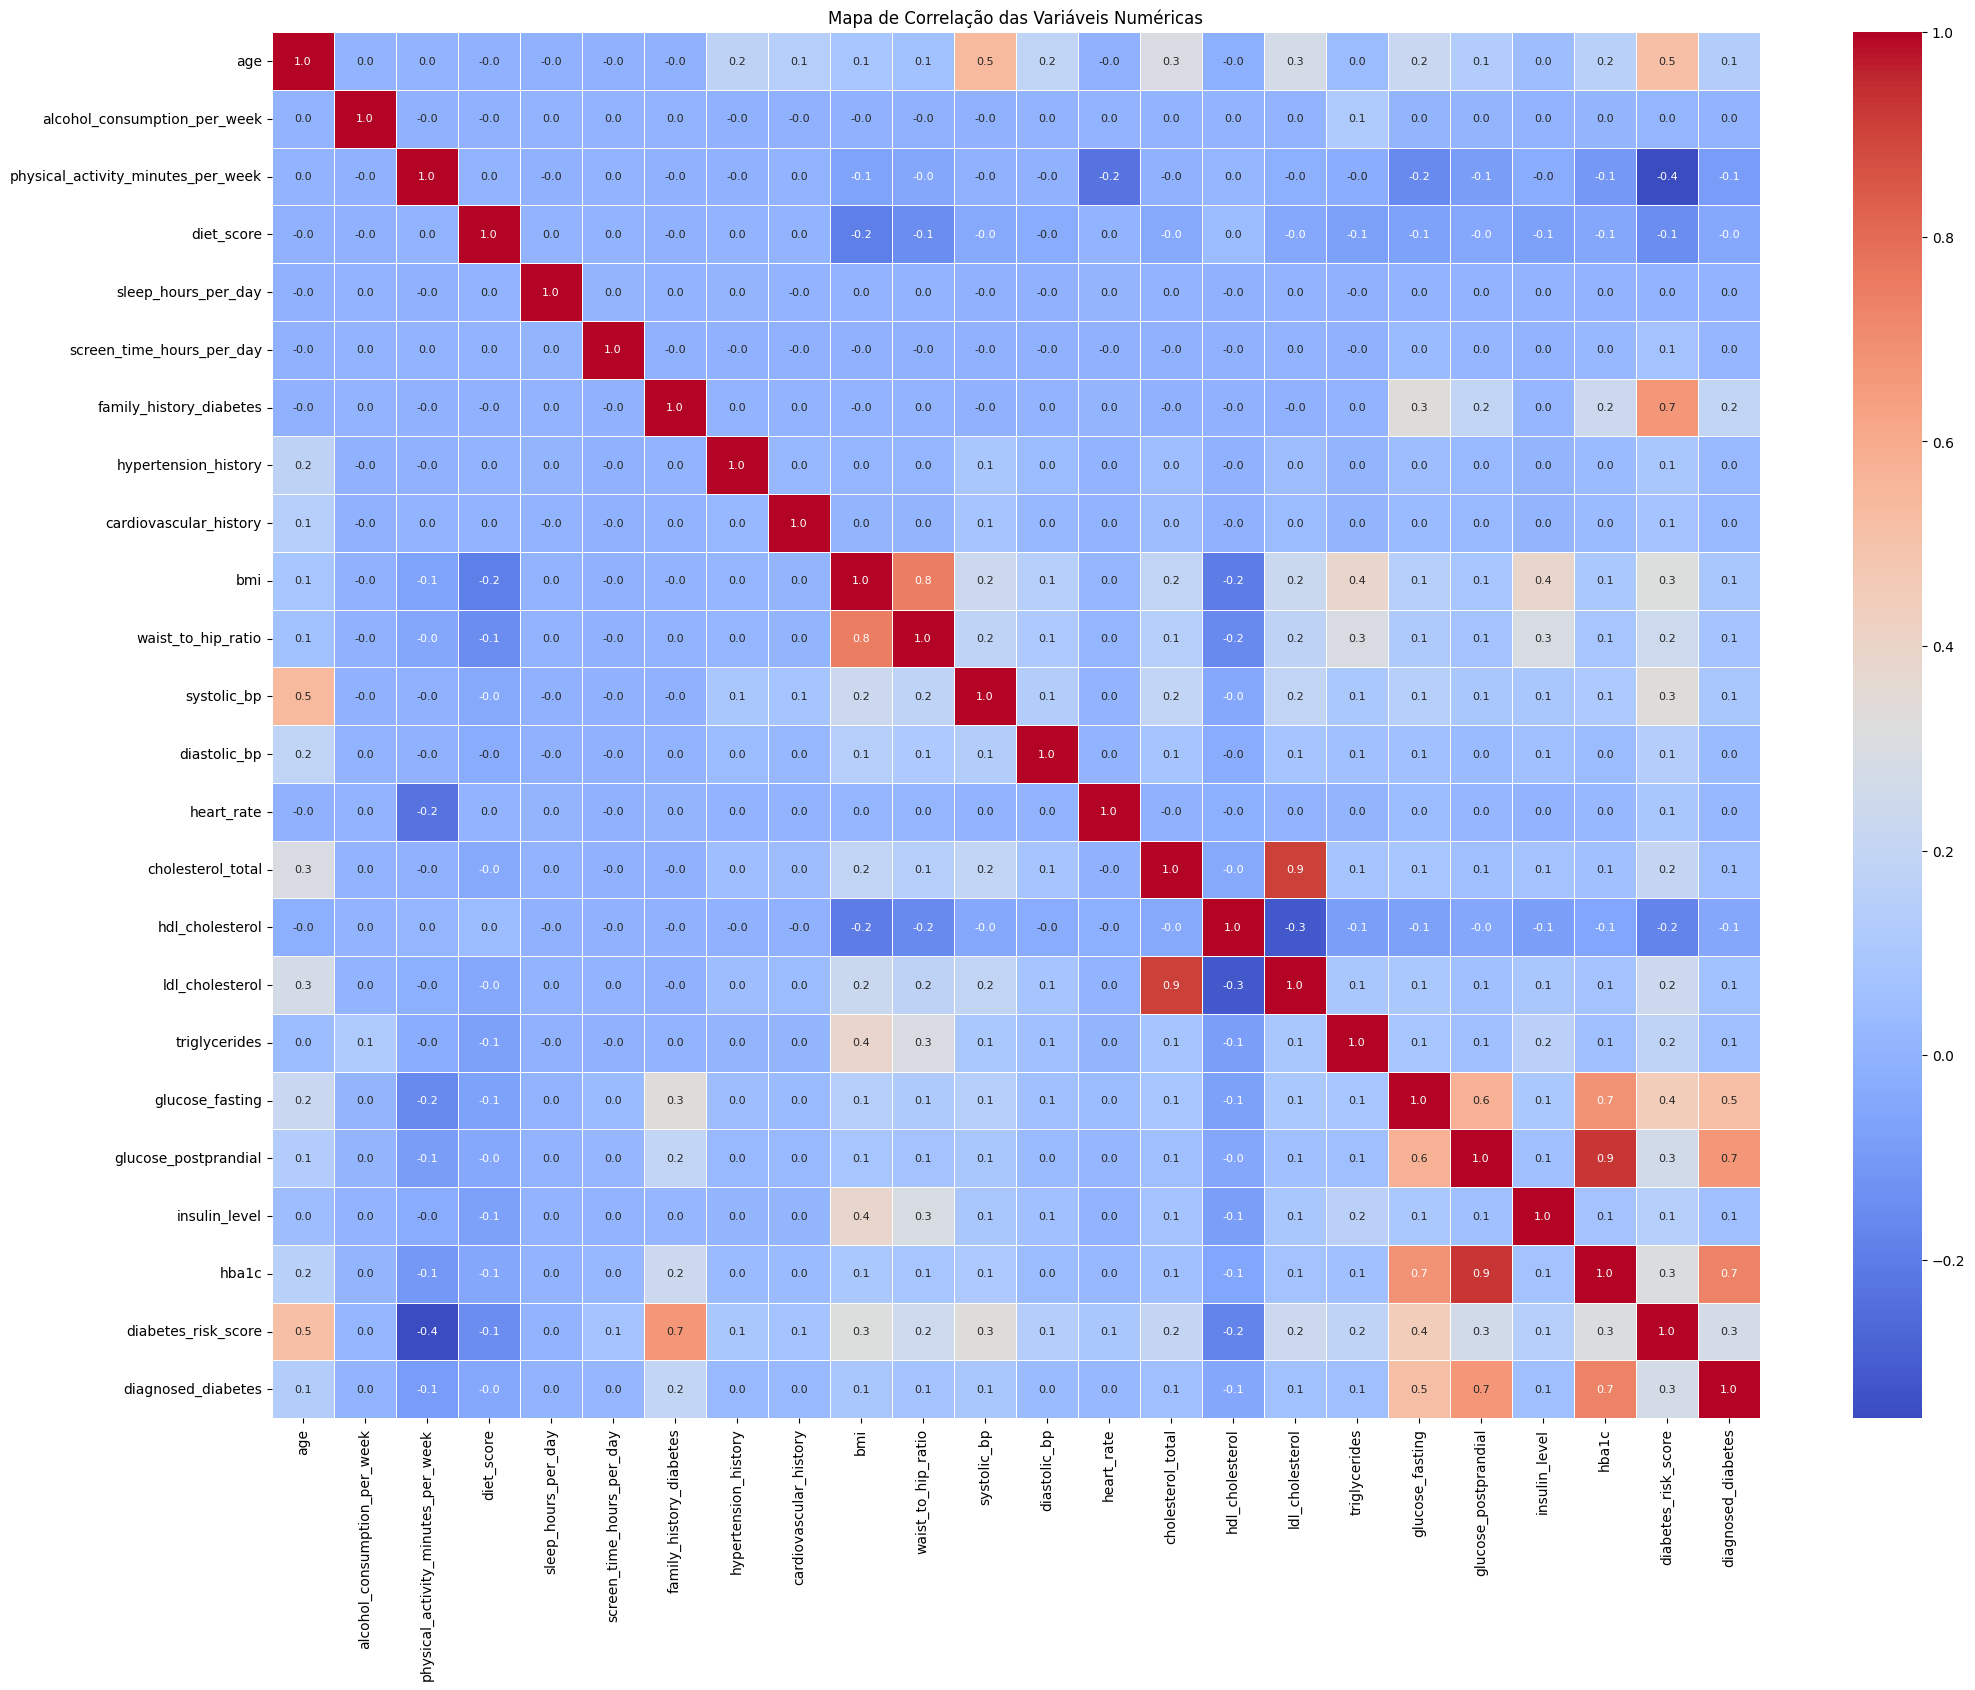

In [96]:
os.makedirs(os.path.join(FIGURES_PATH, 'eda'), exist_ok=True)

corr_matrix = df.corr(method='spearman', numeric_only=True)
plt.figure(figsize=(24, 18))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.1f',
    cmap='coolwarm', 
    linewidths=0.5,
    annot_kws={"size": 8} # Anotações menores
)
plt.title('Mapa de Correlação das Variáveis Numéricas')
plt.savefig(os.path.join(FIGURES_PATH, 'eda', 'heatmap_correlacao.png'), dpi=300, bbox_inches='tight')
plt.show()

#### ==============================================================================
### PERGUNTA 1: Qual é a composição do nosso dataset? (Distribuição do Alvo)
#### ==============================================================================

C:\Users\tteve\AppData\Local\Temp\ipykernel_13460\2681795480.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\tteve\AppData\Local\Temp\ipykernel_13460\2681795480.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Não (0)', 'Sim (1)'])
C:\Users\tteve\AppData\Local\Temp\ipykernel_13460\2681795480.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


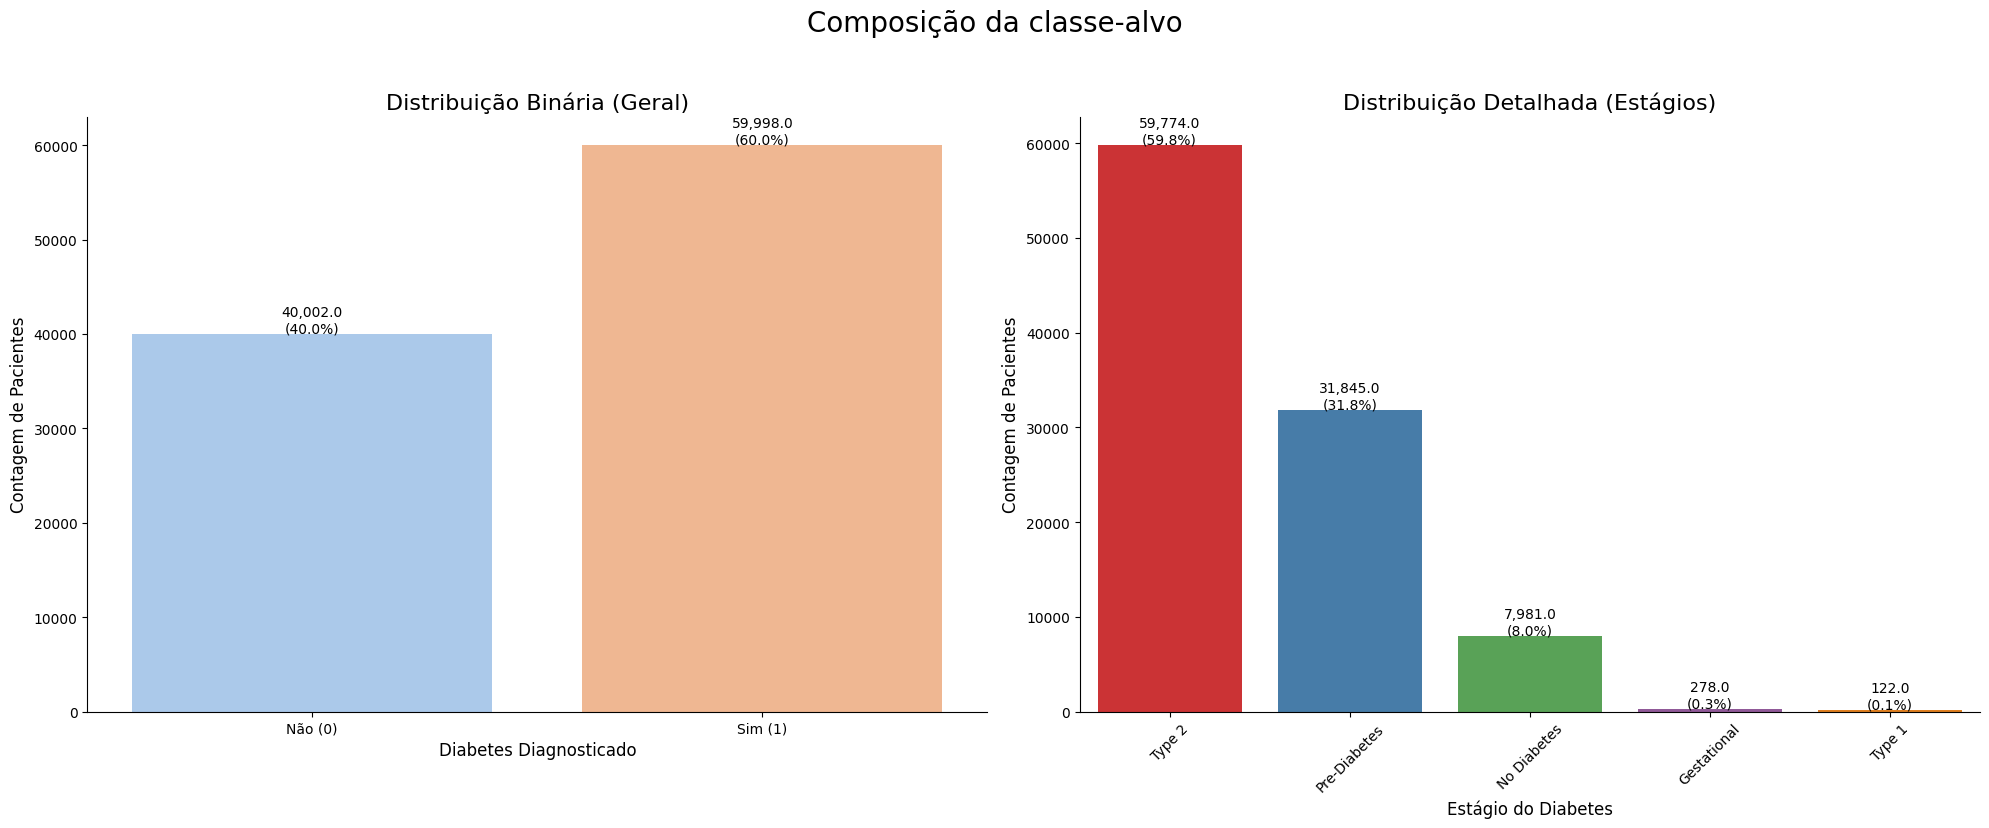

In [97]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
os.makedirs(os.path.join(FIGURES_PATH, 'pergunta01'), exist_ok=True)

# Gráfico 1: Distribuição Binária (Geral)
sns.countplot(
    data=df, 
    x='diagnosed_diabetes', 
    palette='pastel',
    ax=ax1
)
ax1.set_title('Distribuição Binária (Geral)', fontsize=16)
ax1.set_xlabel('Diabetes Diagnosticado', fontsize=12)
ax1.set_ylabel('Contagem de Pacientes', fontsize=12)
ax1.set_xticklabels(['Não (0)', 'Sim (1)'])

for p in ax1.patches:
    ax1.annotate(f'{p.get_height():,}\n({p.get_height()/len(df):.1%})', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Gráfico 2: Distribuição Detalhada (Estágios)
sns.countplot(
    data=df, 
    x='diabetes_stage', 
    order=df['diabetes_stage'].value_counts().index,
    palette='Set1',
    ax=ax2
)

for p in ax2.patches:
    ax2.annotate(f'{p.get_height():,}\n({p.get_height()/len(df):.1%})', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

ax2.set_title('Distribuição Detalhada (Estágios)', fontsize=16)
ax2.set_xlabel('Estágio do Diabetes', fontsize=12)
ax2.set_ylabel('Contagem de Pacientes', fontsize=12)
ax2.tick_params(axis='x', rotation=45)


plt.suptitle('Composição da classe-alvo', fontsize=20, y=1.03)
sns.despine(fig=fig)
plt.tight_layout()

plt.savefig(os.path.join(FIGURES_PATH, 'pergunta01', 'distribuicao_alvo_combinada.png'), dpi=300, bbox_inches='tight')
plt.show()

In [98]:
print("Tabela de Correlação")

tabela_consistencia = pd.crosstab(
    df['diagnosed_diabetes'],
    df['diabetes_stage'] 
)

display(tabela_consistencia)

Tabela de Correlação


diabetes_stage,Gestational,No Diabetes,Pre-Diabetes,Type 1,Type 2
diagnosed_diabetes,,,,,
0,120,7981,31845,56,0
1,158,0,0,66,59774


a partir do gráfico acima, nota-se que:

- alguns casos da diabete gestacional não é diagnosticada como diabetes, talvez seja por que na maioria dos casos é temporária;
- pré-diabetes está sendo diagnosticada como não diabetes (precisamos verificar isso)
- alguns casos do diabetes tipo 1 não está sendo diagnosticada como diabetes.

#### ==============================================================================
### PERGUNTA 2: Qual a relação entre os exames de sangue e o risco de diabetes?
#### ==============================================================================

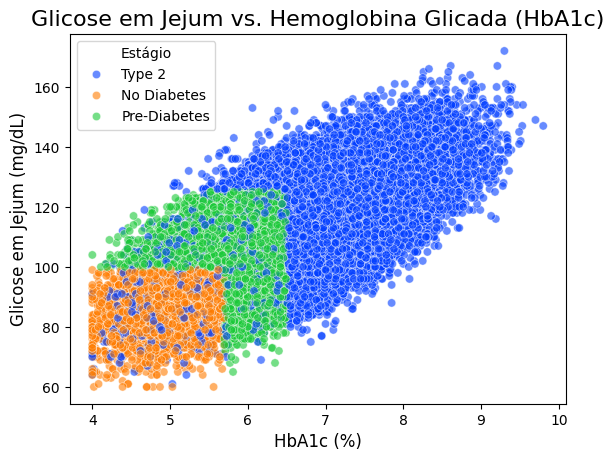

In [99]:
df_subset = df[df['diabetes_stage'].isin(['No Diabetes', 'Pre-Diabetes', 'Type 2'])]
os.makedirs(os.path.join(FIGURES_PATH, 'pergunta02'), exist_ok=True)

sns.scatterplot(
    data=df_subset,
    x='hba1c',
    y='glucose_fasting',
    hue='diabetes_stage',
    palette='bright',
    alpha=0.6
)
plt.title('Glicose em Jejum vs. Hemoglobina Glicada (HbA1c)', fontsize=16)
plt.xlabel('HbA1c (%)', fontsize=12)
plt.ylabel('Glicose em Jejum (mg/dL)', fontsize=12)
plt.legend(title='Estágio')
plt.savefig(os.path.join(FIGURES_PATH, 'pergunta02', 'scatter_hba1c_vs_glicose.png'), dpi=300, bbox_inches='tight')
plt.show()

de acordo com o google:

A concentração normal de glicose no sangue em jejum é de \(70\) a \(99\) mg/dL. Níveis entre \(100\) e \(125\) mg/dL podem indicar pré-diabetes, enquanto valores iguais ou superiores a \(126\) mg/dL (em duas ocasiões) geralmente diagnosticam diabetes.

A HbA1c é um exame de sangue que reflete a média dos níveis de glicose no sangue nos últimos dois a três meses, sendo crucial para diagnosticar e monitorar o diabetes. Um resultado igual ou superior a 6,5% é o ponto de corte para o diagnóstico de diabetes, enquanto valores entre 5,7% e 6,4% indicam pré-diabetes.

#### ==============================================================================
### PERGUNTA 3: Qual é a distribuição exata de idade para pacientes com diabetes?
#### ==============================================================================

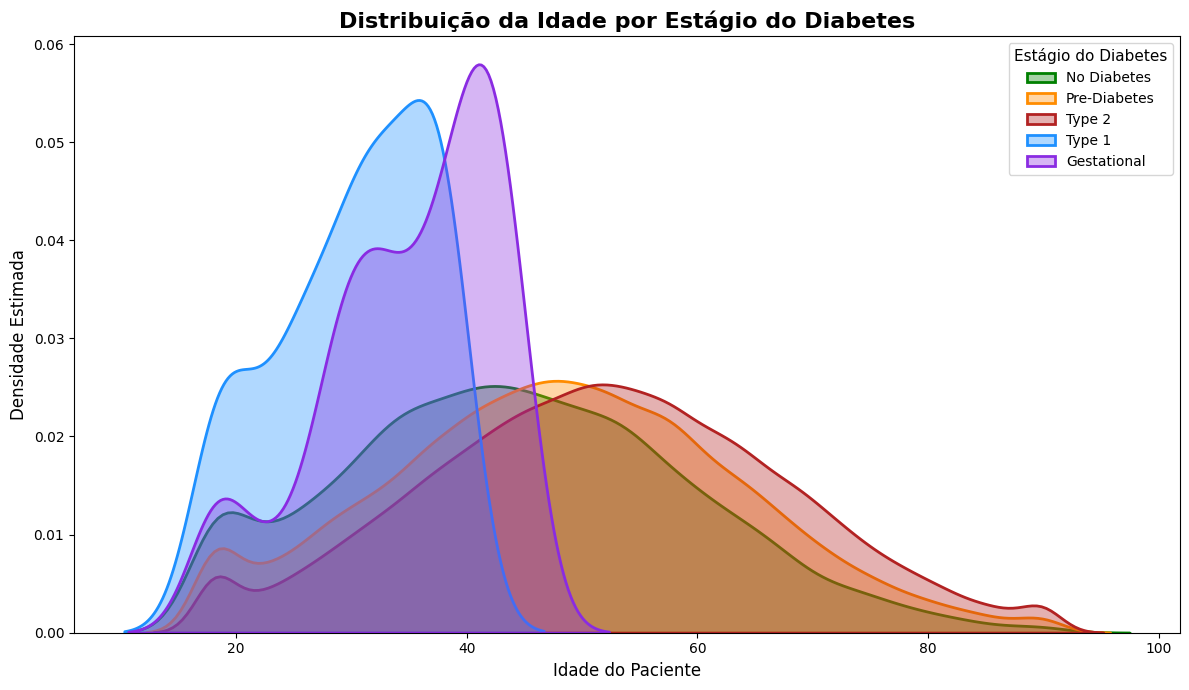

In [100]:
plt.figure(figsize=(12, 7))
os.makedirs(os.path.join(FIGURES_PATH, 'pergunta03'), exist_ok=True)

palette = {
    'No Diabetes': '#008000',
    'Pre-Diabetes': '#FF8C00',
    'Type 2': '#B22222',
    'Type 1': '#1E90FF',
    'Gestational': '#8A2BE2'
}

for stage, color in palette.items():
    subset = df[df['diabetes_stage'] == stage]
    sns.kdeplot(
        data=subset,
        x='age',
        fill=True,
        alpha=0.35,
        linewidth=2,
        color=color,
        label=stage
    )

plt.title('Distribuição da Idade por Estágio do Diabetes', fontsize=16, weight='bold')
plt.xlabel('Idade do Paciente', fontsize=12)
plt.ylabel('Densidade Estimada', fontsize=12)
plt.legend(title='Estágio do Diabetes', fontsize=10, title_fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'pergunta03', 'kde_idade_por_estagio_diabetes.png'), dpi=300, bbox_inches='tight')
plt.show()


# ==============================================================================
# PERGUNTA 4: Fumantes e Colesterol
# ==============================================================================

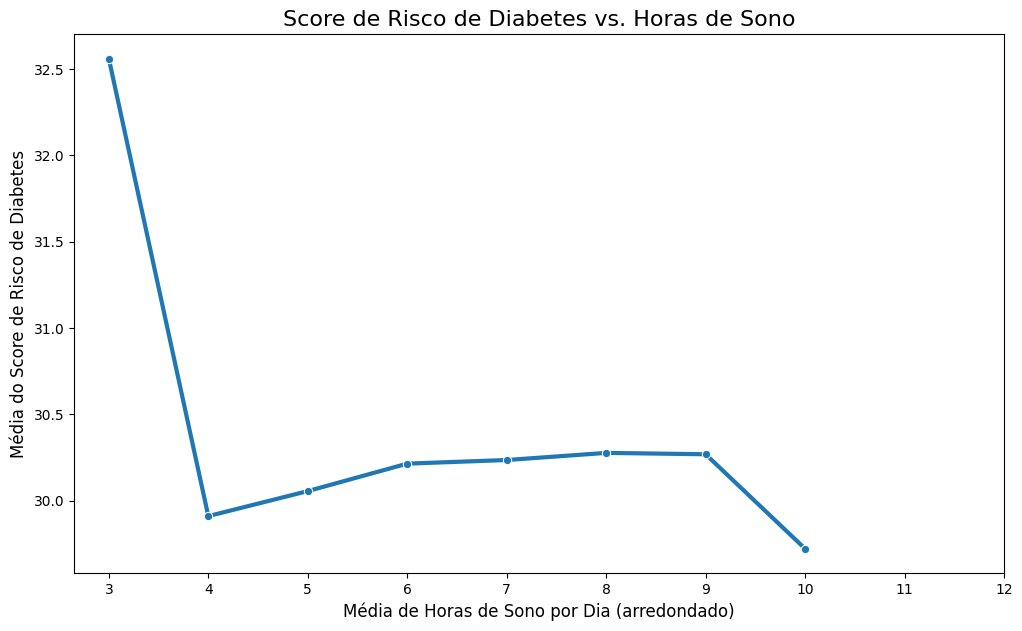

In [101]:
df['sleep_hours_binned'] = df['sleep_hours_per_day'].round()
os.makedirs(os.path.join(FIGURES_PATH, 'pergunta04'), exist_ok=True)

# Calcular a média do score de risco para cada hora de sono
df_sleep = df.groupby('sleep_hours_binned')['diabetes_risk_score'].mean().reset_index()

plt.figure(figsize=(12, 7))
ax = sns.lineplot(
    data=df_sleep,
    x='sleep_hours_binned',
    y='diabetes_risk_score',
    marker='o',
    lw=3
)
ax.set_title('Score de Risco de Diabetes vs. Horas de Sono', fontsize=16)
ax.set_xlabel('Média de Horas de Sono por Dia (arredondado)', fontsize=12)
ax.set_ylabel('Média do Score de Risco de Diabetes', fontsize=12)
ax.set_xticks(range(3, 13)) # Definir ticks para cada hora

plt.savefig(os.path.join(FIGURES_PATH, 'pergunta04', 'risco_por_sono.png'), dpi=300, bbox_inches='tight')
plt.show()


#apagar feature criada

#### ==============================================================================
### PERGUNTA 05: Contagem de Diabetes por Gênero
#### ==============================================================================

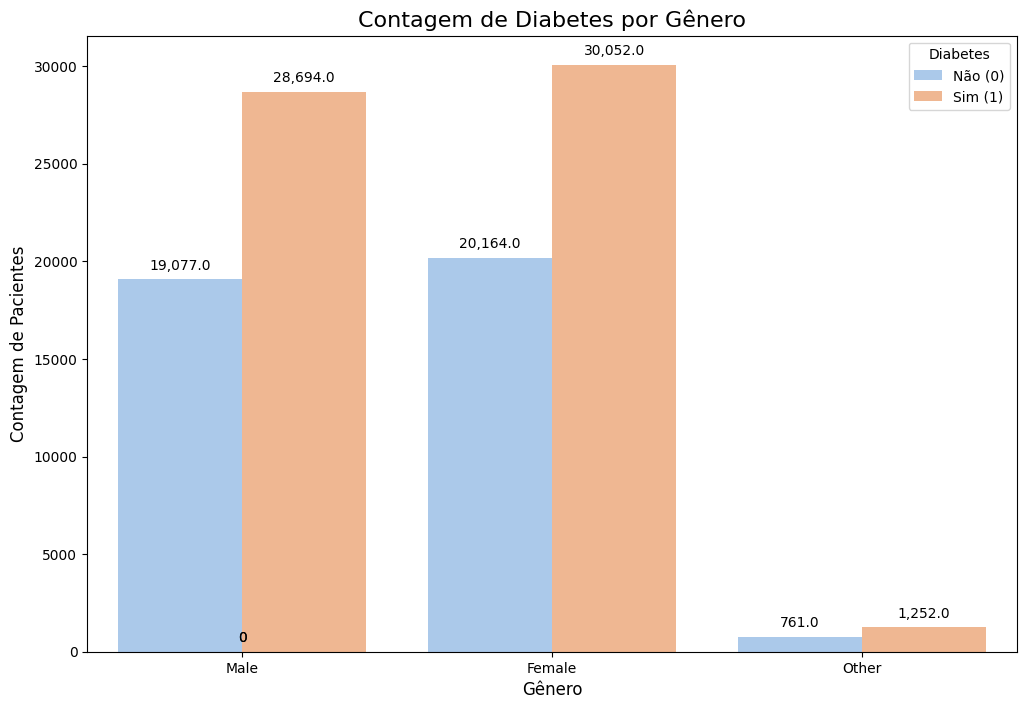

In [102]:
plt.figure(figsize=(12, 8))
os.makedirs(os.path.join(FIGURES_PATH, 'pergunta05'), exist_ok=True)

df_genero = df[df['gender'].isin(['Male', 'Female', 'Other'])]


ax = sns.countplot(
    data=df_genero,
    x='gender',
    hue='diagnosed_diabetes',
    palette='pastel'
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

ax.set_title('Contagem de Diabetes por Gênero', fontsize=16)
ax.set_xlabel('Gênero', fontsize=12)
ax.set_ylabel('Contagem de Pacientes', fontsize=12)

L = plt.legend(title='Diabetes', loc='upper right')
L.get_texts()[0].set_text('Não (0)')
L.get_texts()[1].set_text('Sim (1)')

plt.savefig(os.path.join(FIGURES_PATH, 'pergunta05', 'contagem_genero_vs_diabetes.png'), dpi=300, bbox_inches='tight')
plt.show()

#### ==============================================================================
### PERGUNTA 06: Qual o perfil do diabetes risk score médio para cada faixa etária da população?
#### ==============================================================================

C:\Users\tteve\AppData\Local\Temp\ipykernel_13460\221785446.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_mean_age = df.groupby('age_group')['diabetes_risk_score'].mean().reset_index()
C:\Users\tteve\AppData\Local\Temp\ipykernel_13460\221785446.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['diabetes_stage']


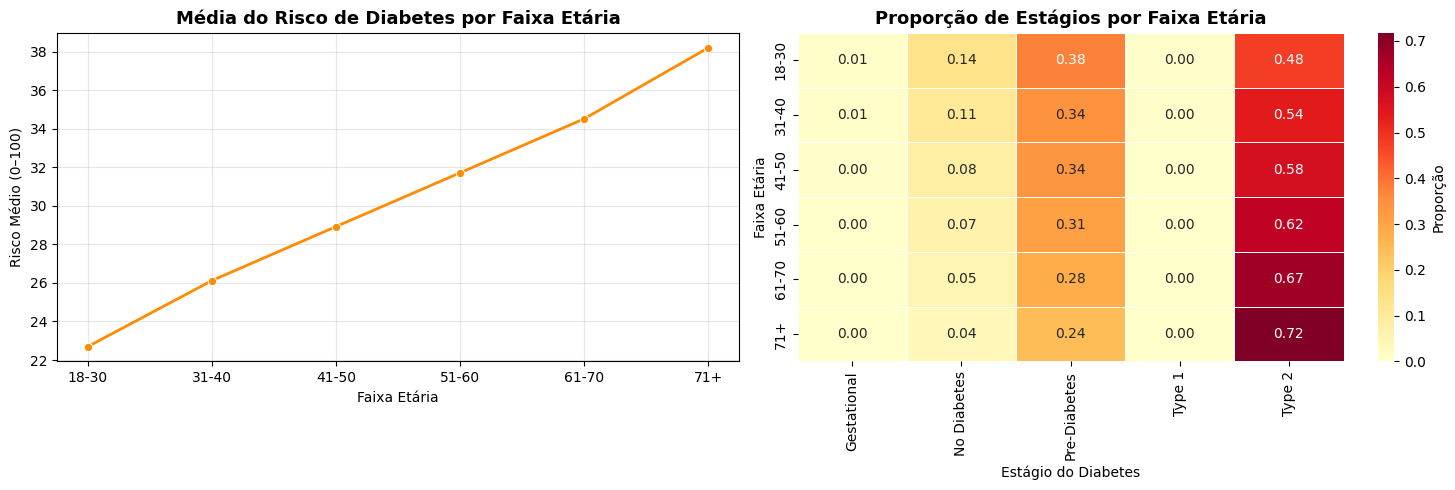

In [ ]:
os.makedirs(os.path.join(FIGURES_PATH, 'pergunta06'), exist_ok=True)

df['age_group'] = pd.cut(
    df['age'],
    bins=[17,30,40,50,60,70,90],
    labels=['18-30','31-40','41-50','51-60','61-70','71+']
)

risk_mean_age = df.groupby('age_group')['diabetes_risk_score'].mean().reset_index()

heat_data = (
    df.groupby('age_group')['diabetes_stage']
      .value_counts(normalize=True)
      .rename('proportion')
      .reset_index()
      .pivot(index='age_group', columns='diabetes_stage', values='proportion')
)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: lineplot
sns.lineplot(
    data=risk_mean_age,
    x='age_group',
    y='diabetes_risk_score',
    marker='o',
    linewidth=2,
    color='#ff8c00',
    ax=axes[0]
)

axes[0].set_title('Média do Risco de Diabetes por Faixa Etária', fontsize=13, weight='bold')
axes[0].set_xlabel('Faixa Etária')
axes[0].set_ylabel('Risco Médio (0–100)')
axes[0].grid(alpha=0.3)

# Gráfico 2: heatmap
sns.heatmap(
    heat_data,
    annot=True,
    cmap='YlOrRd',
    fmt='.2f',
    linewidths=.5,
    cbar_kws={'label': 'Proporção'},
    ax=axes[1]
)

axes[1].set_title('Proporção de Estágios por Faixa Etária', fontsize=13, weight='bold')
axes[1].set_xlabel('Estágio do Diabetes')
axes[1].set_ylabel('Faixa Etária')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'pergunta06', 'lineplot_e_heatmap_faixa_etaria.png'),dpi=300, bbox_inches='tight')
plt.show()

#### ==============================================================================
### PERGUNTA 07: Ter histórico familiar ou hipertensão aumenta o risco médio de diabetes?
#### ==============================================================================

C:\Users\tteve\AppData\Local\Temp\ipykernel_13460\1095506708.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


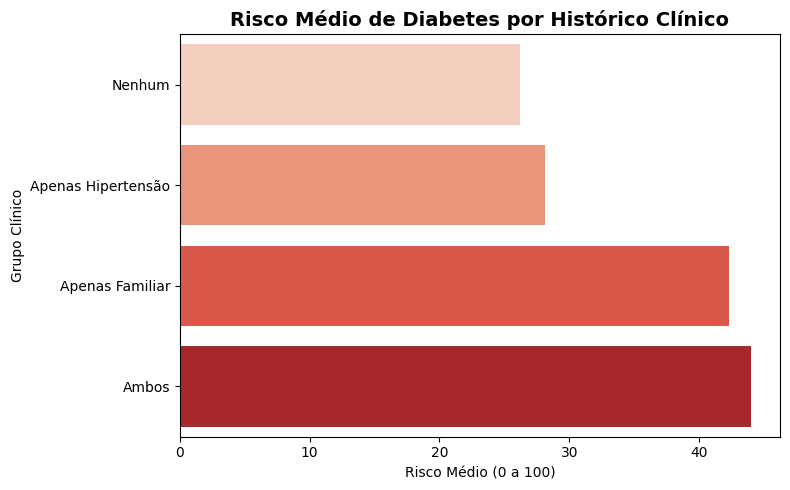

In [126]:
from sklearn.preprocessing import MinMaxScaler

os.makedirs(os.path.join(FIGURES_PATH, 'pergunta07'), exist_ok=True)

# Criando grupos clínicos combinados
df['historico_grupo'] = df.apply(
    lambda x: 
        'Nenhum' if (x['family_history_diabetes'] == 0 and x['hypertension_history'] == 0)
        else 'Apenas Familiar' if (x['family_history_diabetes'] == 1 and x['hypertension_history'] == 0)
        else 'Apenas Hipertensão' if (x['family_history_diabetes'] == 0 and x['hypertension_history'] == 1)
        else 'Ambos'
    , axis=1
)

# Cálculo do risco médio
risk_hist = df.groupby('historico_grupo')['diabetes_risk_score'].mean().reset_index()

# Ordenando do menor para maior risco
risk_hist = risk_hist.sort_values(by='diabetes_risk_score')

plt.figure(figsize=(8,5))
sns.barplot(
    data=risk_hist,
    x='diabetes_risk_score',
    y='historico_grupo',
    palette='Reds'
)

plt.title('Risco Médio de Diabetes por Histórico Clínico', fontsize=14, weight='bold')
plt.xlabel('Risco Médio (0 a 100)')
plt.ylabel('Grupo Clínico')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'pergunta07', 'risco_historico_clinico.png'), dpi=300, bbox_inches='tight')
plt.show()


#### ==============================================================================
### PERGUNTA 08: Qual combinação entre gênero e faixa etária apresenta maior risco médio de diabetes?
#### ==============================================================================

C:\Users\tteve\AppData\Local\Temp\ipykernel_13460\1090804649.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = df.groupby(['age_group', 'gender'])['diabetes_risk_score'].mean().reset_index()


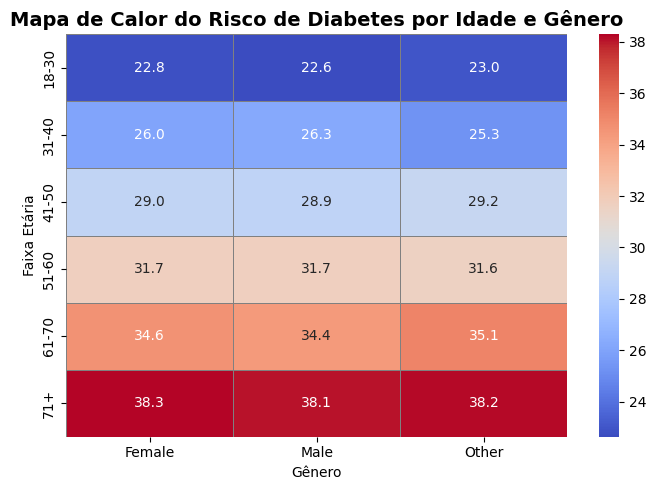

In [127]:
os.makedirs(os.path.join(FIGURES_PATH, 'pergunta08'), exist_ok=True)

# Cálculo da média por faixa etária e gênero
heat = df.groupby(['age_group', 'gender'])['diabetes_risk_score'].mean().reset_index()

# Pivot para heatmap
heat_pivot = heat.pivot(index='age_group', columns='gender', values='diabetes_risk_score')

plt.figure(figsize=(7,5))
sns.heatmap(
    heat_pivot,
    annot=True,
    fmt='.1f',
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Mapa de Calor do Risco de Diabetes por Idade e Gênero', fontsize=14, weight='bold')
plt.xlabel('Gênero')
plt.ylabel('Faixa Etária')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'pergunta08', 'heatmap_idade_genero_risco.png'), dpi=300, bbox_inches='tight')
plt.show()
